"""
# Notebook 35 — State-aware scheduling policy family

## Goal

Evaluate a small family of rule-based state-aware DC–AC scheduling policies.

Notebook 34 showed that a single Day33-informed scheduled waveform can improve hard negative-electrode margin while retaining geometry-dominated raw timing gain. Notebook 35 extends this from one schedule to a small, interpretable policy family.

Core question:

> Which state-aware scheduling policies provide the best trade-off between raw timing gain, negative-electrode margin, and microstate stress?

## Scientific context

The DC–AC project is no longer searching for the fastest fixed sinusoidal protocol. The current goal is to identify admissible fast protocols under multiple constraints:

1. state-equivalent timing gain,
2. geometry–residual separation,
3. microstate response,
4. negative-electrode plating margin,
5. future thermal / aging admissibility.

Prior results:

- Notebook 30: raw timing gain is geometry-dominated; microstate response exists.
- Notebook 31: Chen2020 / DFN has a hard-margin boundary near AC≈0.386C at fixed 1.5τ_set.
- Notebook 32: timing geometry dominance transfers; plating-margin admissibility is parameter-set dependent.
- Notebook 33: plating-margin risk localizes near high-Q / voltage-boundary-adjacent operation and is phase-locked to AC charge-current peaks.
- Notebook 34: scheduled v1 improves hard negative-electrode margin while retaining raw timing gain comparable to fixed AC0.38.

## Day35 policy-family idea

Notebook 35 does not implement MPC or Bayesian optimization. Instead, it defines a small policy family that can later become MPC/BO-ready.

Each scheduled policy has:

- early AC amplitude,
- mid AC amplitude,
- derating threshold in Q_ref fraction,
- AC-off threshold in Q_ref fraction.

The schedules are pre-programmed using the DC-reference Q progression as a time proxy.

## Policy family

Baseline protocols:

- pure DC `0.3C`
- fixed `0.3C + 0.38C`
- fixed `0.3C + 0.7C`

Scheduled policies:

| policy | early AC | mid AC | derate threshold | AC-off threshold | role |
|---|---:|---:|---:|---:|---|
| v1 | 0.38C | 0.20C | 0.75 Q_ref | 0.85 Q_ref | Day34 baseline |
| v2 | 0.38C | 0.10C | 0.70 Q_ref | 0.80 Q_ref | conservative |
| v3 | 0.38C | 0.20C | 0.70 Q_ref | 0.85 Q_ref | earlier derating |
| v4 | 0.38C | 0.20C | 0.80 Q_ref | 0.90 Q_ref | aggressive |
| v5 | 0.30C | 0.10C | 0.75 Q_ref | 0.85 Q_ref | low-stress |

## Outputs

Expected first-stage outputs:

- `data/day35_metadata.json`
- `data/day35_policy_table.csv`
- `data/day35_current_waveform_audit.csv`
- `data/day35_current_waveform_summary.csv`

Later outputs will include:

- PyBaMM run summaries,
- timing geometry–residual summaries,
- plating-margin summaries,
- microstate-context summaries,
- gain–margin–microstate policy ranking.

## Interpretation boundary

Notebook 35 evaluates a small policy family. It is not global optimization, MPC, Bayesian optimization, thermal validation, or aging validation.

In [1]:
# Cell 1 — Imports, paths, and Day35 metadata（导入库、路径与Day35元数据）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_DIR = REPO / "docs"

for p in [DATA_DIR, FIG_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"
FREQUENCY_MODE = "set_rebased"

DC_C = 0.3
TAU_FACTOR_MAIN = 1.5
TAU_REF_SET_S = 36.316532231592305
F_MAIN_HZ = 1.0 / (2.0 * np.pi * TAU_FACTOR_MAIN * TAU_REF_SET_S)
PERIOD_MAIN_S = 1.0 / F_MAIN_HZ

PLATING_MARGIN_SAFE_BUFFER_V = 0.050

DAY35_METADATA = {
    "notebook": "35_state_aware_policy_family.ipynb",
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "frequency_mode": FREQUENCY_MODE,
    "tau_factor_main": TAU_FACTOR_MAIN,
    "tau_ref_set_s": TAU_REF_SET_S,
    "f_main_Hz": F_MAIN_HZ,
    "purpose": "evaluate small state-aware DCAC scheduling policy family",
    "not_mpc_or_bo": True,
    "lineage": "Day35 extends Day34 rule-based scheduled waveform v1 to a small policy family.",
}

metadata_path = DATA_DIR / "day35_metadata.json"
metadata_path.write_text(json.dumps(DAY35_METADATA, indent=2), encoding="utf-8")

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] f_main_Hz:", F_MAIN_HZ)
print("[OK] period_main_s:", PERIOD_MAIN_S)
print("[OK] saved metadata:", metadata_path)

[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] f_main_Hz: 0.002921625190367048
[OK] period_main_s: 342.27525258788194
[OK] saved metadata: /Users/louislu/pybamm-dcac-superimposed/data/day35_metadata.json


In [2]:
# Cell 2 — Load references and define schedule breakpoint utilities（读取参考量并定义调度断点工具）

# Prefer Day34 or Day33 DC reference Q_end.
candidate_ref_files = [
    DATA_DIR / "day34_run_summary.csv",
    DATA_DIR / "day33b_run_summary.csv",
]

Q_REF_AH = None

for path in candidate_ref_files:
    if path.exists():
        df = pd.read_csv(path)
        possible_dc_rows = df[
            df["condition"].astype(str).str.contains("DC03")
            & (df["condition"].astype(str).str.contains("DCAC") == False)
        ]
        if len(possible_dc_rows) > 0 and "Q_end_Ah" in possible_dc_rows.columns:
            Q_REF_AH = float(possible_dc_rows["Q_end_Ah"].iloc[0])
            print("[OK] Q_REF_AH loaded from:", path)
            break

if Q_REF_AH is None:
    Q_REF_AH = 4.4928790028035
    print("[WARN] fallback Q_REF_AH used:", Q_REF_AH)

parameter_values_ref = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
Q_NOM_AH = float(parameter_values_ref["Nominal cell capacity [A.h]"])
I_DC_A = DC_C * Q_NOM_AH

def qfrac_to_time_s(q_frac):
    return q_frac * Q_REF_AH * 3600.0 / I_DC_A

print("[OK] Q_NOM_AH:", Q_NOM_AH)
print("[OK] Q_REF_AH:", Q_REF_AH)
print("[OK] I_DC_A:", I_DC_A)

# Check the Day34 v1 breakpoints.
print("[CHECK] 0.75 Qref time [min]:", qfrac_to_time_s(0.75) / 60.0)
print("[CHECK] 0.85 Qref time [min]:", qfrac_to_time_s(0.85) / 60.0)

[OK] Q_REF_AH loaded from: /Users/louislu/pybamm-dcac-superimposed/data/day34_run_summary.csv
[OK] Q_NOM_AH: 5.0
[OK] Q_REF_AH: 4.4928790028035
[OK] I_DC_A: 1.5
[CHECK] 0.75 Qref time [min]: 134.78637008410502
[CHECK] 0.85 Qref time [min]: 152.75788609531898


In [3]:
# Cell 3 — Define Day35 policy family（定义Day35策略族）

policy_rows = []

# Baselines
policy_rows.extend([
    {
        "policy_id": "DC03",
        "condition": "Chen2020_DFN_Day35_DC03",
        "protocol_type": "DC",
        "case_role": "dc_reference",
        "schedule_type": "constant",
        "dc_c": DC_C,
        "fixed_ac_c": 0.0,
        "early_ac_c": 0.0,
        "mid_ac_c": 0.0,
        "late_ac_c": 0.0,
        "qfrac_derate": np.nan,
        "qfrac_ac_off": np.nan,
        "tau_factor_set": np.nan,
        "f_Hz": np.nan,
        "period_s": np.nan,
        "policy_note": "pure DC reference",
    },
    {
        "policy_id": "fixed_AC0p38",
        "condition": "Chen2020_DFN_Day35_fixed_AC0p38",
        "protocol_type": "DCAC",
        "case_role": "fixed_near_boundary_baseline",
        "schedule_type": "constant",
        "dc_c": DC_C,
        "fixed_ac_c": 0.38,
        "early_ac_c": 0.38,
        "mid_ac_c": 0.38,
        "late_ac_c": 0.38,
        "qfrac_derate": np.nan,
        "qfrac_ac_off": np.nan,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "policy_note": "fixed near-boundary baseline",
    },
    {
        "policy_id": "fixed_AC0p7",
        "condition": "Chen2020_DFN_Day35_fixed_AC0p7",
        "protocol_type": "DCAC",
        "case_role": "fixed_stress_baseline",
        "schedule_type": "constant",
        "dc_c": DC_C,
        "fixed_ac_c": 0.70,
        "early_ac_c": 0.70,
        "mid_ac_c": 0.70,
        "late_ac_c": 0.70,
        "qfrac_derate": np.nan,
        "qfrac_ac_off": np.nan,
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "policy_note": "fixed high-amplitude stress baseline",
    },
])

# Scheduled policies.
scheduled_specs = [
    {
        "policy_id": "sched_v1_day34",
        "case_role": "scheduled_v1_day34_baseline",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.20,
        "late_ac_c": 0.00,
        "qfrac_derate": 0.75,
        "qfrac_ac_off": 0.85,
        "policy_note": "Day34 scheduled baseline",
    },
    {
        "policy_id": "sched_v2_conservative",
        "case_role": "scheduled_v2_conservative",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.10,
        "late_ac_c": 0.00,
        "qfrac_derate": 0.70,
        "qfrac_ac_off": 0.80,
        "policy_note": "earlier derating and earlier AC-off",
    },
    {
        "policy_id": "sched_v3_early_derate",
        "case_role": "scheduled_v3_early_derate",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.20,
        "late_ac_c": 0.00,
        "qfrac_derate": 0.70,
        "qfrac_ac_off": 0.85,
        "policy_note": "early derating, same AC-off as v1",
    },
    {
        "policy_id": "sched_v4_aggressive",
        "case_role": "scheduled_v4_aggressive",
        "early_ac_c": 0.38,
        "mid_ac_c": 0.20,
        "late_ac_c": 0.00,
        "qfrac_derate": 0.80,
        "qfrac_ac_off": 0.90,
        "policy_note": "later derating and later AC-off",
    },
    {
        "policy_id": "sched_v5_low_stress",
        "case_role": "scheduled_v5_low_stress",
        "early_ac_c": 0.30,
        "mid_ac_c": 0.10,
        "late_ac_c": 0.00,
        "qfrac_derate": 0.75,
        "qfrac_ac_off": 0.85,
        "policy_note": "lower early and mid AC amplitude",
    },
]

for spec in scheduled_specs:
    policy_rows.append({
        "policy_id": spec["policy_id"],
        "condition": f"Chen2020_DFN_Day35_{spec['policy_id']}",
        "protocol_type": "DCAC_SCHEDULED",
        "case_role": spec["case_role"],
        "schedule_type": "qfrac_time_proxy",
        "dc_c": DC_C,
        "fixed_ac_c": np.nan,
        "early_ac_c": spec["early_ac_c"],
        "mid_ac_c": spec["mid_ac_c"],
        "late_ac_c": spec["late_ac_c"],
        "qfrac_derate": spec["qfrac_derate"],
        "qfrac_ac_off": spec["qfrac_ac_off"],
        "tau_factor_set": TAU_FACTOR_MAIN,
        "f_Hz": F_MAIN_HZ,
        "period_s": PERIOD_MAIN_S,
        "policy_note": spec["policy_note"],
    })

policy_df = pd.DataFrame(policy_rows)
policy_df["peak_c_nominal"] = policy_df["dc_c"] + policy_df[["fixed_ac_c", "early_ac_c"]].max(axis=1)

out = DATA_DIR / "day35_policy_table.csv"
policy_df.to_csv(out, index=False)

print("[OK] saved policy table:", out)
display(policy_df)

[OK] saved policy table: /Users/louislu/pybamm-dcac-superimposed/data/day35_policy_table.csv


,policy_id,condition,protocol_type,case_role,schedule_type,dc_c,fixed_ac_c,early_ac_c,mid_ac_c,late_ac_c,qfrac_derate,qfrac_ac_off,tau_factor_set,f_Hz,period_s,policy_note,peak_c_nominal
0,DC03,Chen2020_DFN_Day35_DC03,DC,dc_reference,constant,0.3,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,pure DC reference,0.30
1,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,DCAC,fixed_near_boundary_baseline,constant,0.3,0.38,0.38,0.38,0.38,NaN,NaN,1.5,0.002922,342.275253,fixed near-boundary baseline,0.68
2,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,DCAC,fixed_stress_baseline,constant,0.3,0.70,0.70,0.70,0.70,NaN,NaN,1.5,0.002922,342.275253,fixed high-amplitude stress baseline,1.00
3,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,DCAC_SCHEDULED,scheduled_v1_day34_baseline,qfrac_time_proxy,0.3,NaN,0.38,0.20,0.00,0.75,0.85,1.5,0.002922,342.275253,Day34 scheduled baseline,0.68
4,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,DCAC_SCHEDULED,scheduled_v2_conservative,qfrac_time_proxy,0.3,NaN,0.38,0.10,0.00,0.70,0.80,1.5,0.002922,342.275253,earlier derating and earlier AC-off,0.68
5,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,DCAC_SCHEDULED,scheduled_v3_early_derate,qfrac_time_proxy,0.3,NaN,0.38,0.20,0.00,0.70,0.85,1.5,0.002922,342.275253,"early derating, same AC-off as v1",0.68
6,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,DCAC_SCHEDULED,scheduled_v4_aggressive,qfrac_time_proxy,0.3,NaN,0.38,0.20,0.00,0.80,0.90,1.5,0.002922,342.275253,later derating and later AC-off,0.68
7,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,DCAC_SCHEDULED,scheduled_v5_low_stress,qfrac_time_proxy,0.3,NaN,0.30,0.10,0.00,0.75,0.85,1.5,0.002922,342.275253,lower early and mid AC amplitude,0.60


In [4]:
# Cell 4 — Current waveform utilities for policy family（策略族电流波形工具）

def ac_amplitude_c_at_time_policy(t_s, policy_row):
    stype = policy_row["schedule_type"]
    t_s = np.asarray(t_s, dtype=float)

    if stype == "constant":
        return np.full_like(t_s, float(policy_row["fixed_ac_c"]), dtype=float)

    if stype == "qfrac_time_proxy":
        t_derate = qfrac_to_time_s(float(policy_row["qfrac_derate"]))
        t_off = qfrac_to_time_s(float(policy_row["qfrac_ac_off"]))

        ac = np.zeros_like(t_s, dtype=float)
        ac[t_s < t_derate] = float(policy_row["early_ac_c"])
        ac[(t_s >= t_derate) & (t_s < t_off)] = float(policy_row["mid_ac_c"])
        ac[t_s >= t_off] = float(policy_row["late_ac_c"])
        return ac

    raise ValueError(f"Unknown schedule_type: {stype}")


def charge_current_A_policy(t_s, policy_row, q_nom_Ah=Q_NOM_AH):
    t_s = np.asarray(t_s, dtype=float)
    i_dc = float(policy_row["dc_c"]) * q_nom_Ah
    ac_c = ac_amplitude_c_at_time_policy(t_s, policy_row)
    i_ac = ac_c * q_nom_Ah

    if pd.isna(policy_row["f_Hz"]) or float(policy_row["f_Hz"]) == 0:
        return i_dc + np.zeros_like(t_s)

    f_hz = float(policy_row["f_Hz"])
    return i_dc + i_ac * np.sin(2.0 * np.pi * f_hz * t_s)


def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])


def sample_policy_waveform(policy_row, t_max_s=12000, dt_s=0.5):
    t = np.arange(0.0, t_max_s + dt_s, dt_s)
    i_charge = charge_current_A_policy(t, policy_row)
    q_geom = cumulative_trapezoid_np(i_charge, t) / 3600.0
    ac_c = ac_amplitude_c_at_time_policy(t, policy_row)

    return pd.DataFrame({
        "t_s": t,
        "I_charge_A": i_charge,
        "I_py_A": -i_charge,
        "Q_geom_Ah": q_geom,
        "AC_C_scheduled": ac_c,
    })

print("[OK] Day35 waveform utilities ready")

[OK] Day35 waveform utilities ready


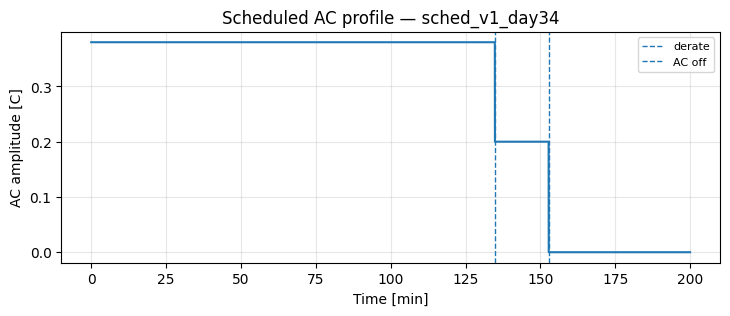

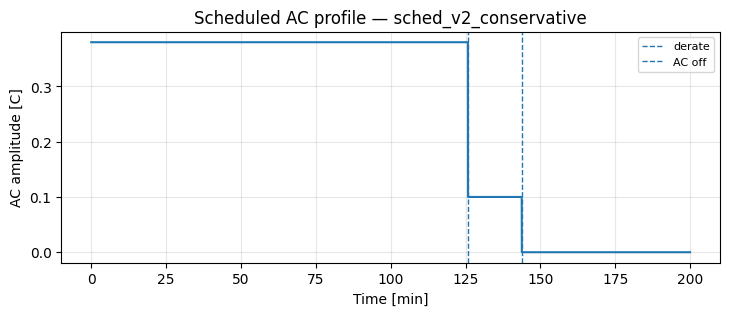

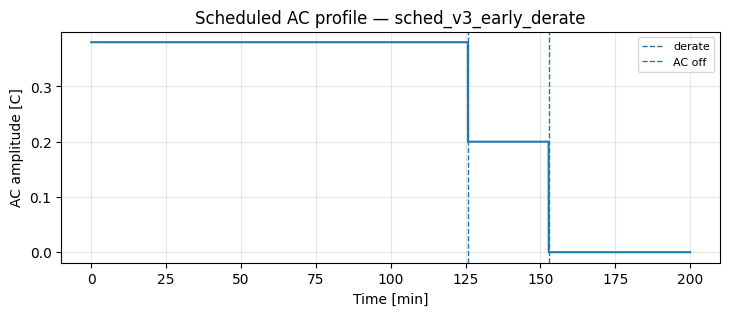

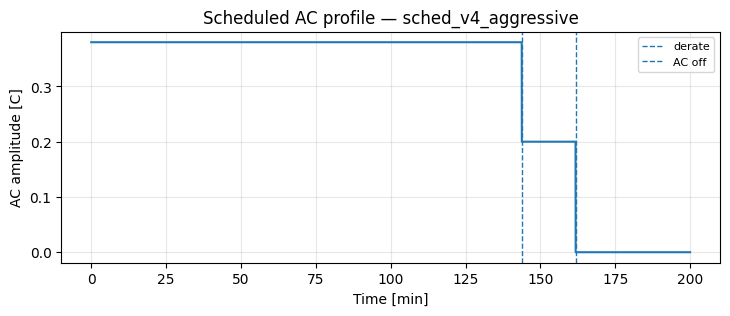

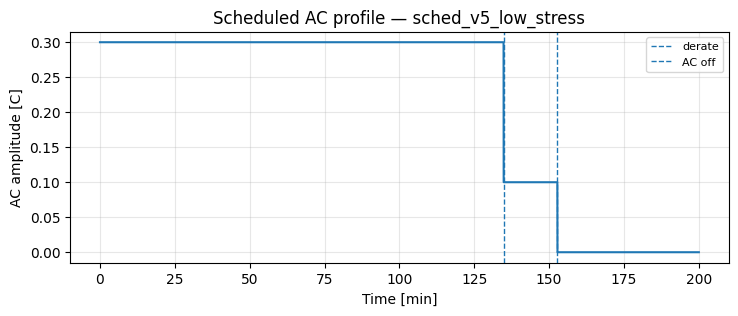

[OK] saved waveform audit: /Users/louislu/pybamm-dcac-superimposed/data/day35_current_waveform_audit.csv
[OK] saved waveform summary: /Users/louislu/pybamm-dcac-superimposed/data/day35_current_waveform_summary.csv


,policy_id,condition,I_charge_min_A,I_charge_max_A,Q_geom_end_Ah,AC_C_min,AC_C_max
0,DC03,Chen2020_DFN_Day35_DC03,1.500000e+00,1.5,5.000000,0.00,0.00
1,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,-4.000000e-01,3.4,5.001986,0.38,0.38
2,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,-2.000000e+00,5.0,5.031072,0.70,0.70
3,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,-4.000000e-01,3.4,5.035608,0.00,0.38
4,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,-4.000000e-01,3.4,5.006519,0.00,0.38
5,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,-4.000000e-01,3.4,5.013290,0.00,0.38
6,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,-4.000000e-01,3.4,5.033932,0.00,0.38
7,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,2.266811e-08,3.0,5.031903,0.00,0.30


In [5]:

waveform_records = []

for _, row in policy_df.iterrows():
    wf = sample_policy_waveform(row.to_dict(), t_max_s=12000, dt_s=0.5)
    wf["condition"] = row["condition"]
    wf["policy_id"] = row["policy_id"]
    waveform_records.append(wf)

    if row["protocol_type"] == "DCAC_SCHEDULED":
        fig, ax = plt.subplots(figsize=(8.5, 3.0))
        ax.plot(wf["t_s"] / 60, wf["AC_C_scheduled"])
        ax.axvline(qfrac_to_time_s(row["qfrac_derate"]) / 60, linestyle="--", linewidth=1, label="derate")
        ax.axvline(qfrac_to_time_s(row["qfrac_ac_off"]) / 60, linestyle="--", linewidth=1, label="AC off")
        ax.set_xlabel("Time [min]")
        ax.set_ylabel("AC amplitude [C]")
        ax.set_title(f"Scheduled AC profile — {row['policy_id']}")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        plt.show()

waveform_df = pd.concat(waveform_records, ignore_index=True)

out = DATA_DIR / "day35_current_waveform_audit.csv"
waveform_df.to_csv(out, index=False)

waveform_summary_df = (
    waveform_df
    .groupby(["policy_id", "condition"], as_index=False)
    .agg(
        I_charge_min_A=("I_charge_A", "min"),
        I_charge_max_A=("I_charge_A", "max"),
        Q_geom_end_Ah=("Q_geom_Ah", "max"),
        AC_C_min=("AC_C_scheduled", "min"),
        AC_C_max=("AC_C_scheduled", "max"),
    )
)

out_summary = DATA_DIR / "day35_current_waveform_summary.csv"
waveform_summary_df.to_csv(out_summary, index=False)

print("[OK] saved waveform audit:", out)
print("[OK] saved waveform summary:", out_summary)
display(waveform_summary_df)

In [6]:
# Cell 6 — PyBaMM simulation utilities for Day35 policy family（Day35策略族PyBaMM仿真工具）

def make_model(model_type="DFN"):
    if model_type == "DFN":
        return pybamm.lithium_ion.DFN({"thermal": "isothermal"})
    if model_type == "SPMe":
        return pybamm.lithium_ion.SPMe({"thermal": "isothermal"})
    if model_type == "SPM":
        return pybamm.lithium_ion.SPM({"thermal": "isothermal"})
    raise ValueError(f"Unknown model_type: {model_type}")


def make_parameter_values_with_policy_current(policy_row, max_time_s=24000, current_dt_s=1.0):
    """
    Interpolated prescribed-current profile for fixed and scheduled policies.

    PyBaMM convention:
    +I = discharge
    -I = charge

    External charge-positive current:
    I_charge(t) = I_DC + A_AC(t) sin(2πft)

    PyBaMM current:
    I_py(t) = -I_charge(t)
    """
    pv = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
    q_nom_Ah = float(pv["Nominal cell capacity [A.h]"])

    t_grid = np.arange(0.0, max_time_s + current_dt_s, current_dt_s)
    i_charge_grid = charge_current_A_policy(t_grid, policy_row, q_nom_Ah=q_nom_Ah)
    i_py_grid = -i_charge_grid

    current_interpolant = pybamm.Interpolant(
        t_grid,
        i_py_grid,
        pybamm.t,
        interpolator="linear",
    )

    pv.update({"Current function [A]": current_interpolant}, check_already_exists=False)

    q_geom_grid = cumulative_trapezoid_np(i_charge_grid, t_grid) / 3600.0
    ac_c_grid = ac_amplitude_c_at_time_policy(t_grid, policy_row)

    geom_df = pd.DataFrame({
        "t_s": t_grid,
        "I_charge_A": i_charge_grid,
        "I_py_A": i_py_grid,
        "Q_geom_Ah": q_geom_grid,
        "AC_C_scheduled": ac_c_grid,
    })

    meta = {
        "nominal_capacity_Ah": q_nom_Ah,
        "max_time_s": max_time_s,
        "current_dt_s": current_dt_s,
        "phase_convention": "charge_first",
        "current_definition": "I_py(t) = -I_charge(t), interpolated prescribed profile",
    }

    return pv, geom_df, meta


def extract_basic_timeseries(sol):
    t_s = np.asarray(sol.t, dtype=float)
    I_py_A = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    V_terminal_V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)

    I_charge_A = -I_py_A
    Q_net_Ah = cumulative_trapezoid_np(I_charge_A, t_s) / 3600.0

    return pd.DataFrame({
        "t_s": t_s,
        "I_py_A": I_py_A,
        "I_charge_A": I_charge_A,
        "V_terminal_V": V_terminal_V,
        "Q_net_Ah": Q_net_Ah,
    })


def run_day35_simulation(policy_row, initial_soc=0.05, max_time_s=24000, n_eval=5000, current_dt_s=1.0):
    model = make_model(MODEL_TYPE)
    pv, geom_df, meta = make_parameter_values_with_policy_current(
        policy_row=policy_row,
        max_time_s=max_time_s,
        current_dt_s=current_dt_s,
    )

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return sim, sol, ts, geom_df, meta

print("[OK] Day35 simulation utilities ready")

[OK] Day35 simulation utilities ready


In [7]:
# Cell 7 — Run Day35 policy-family simulations（运行Day35策略族仿真）

solutions = {}
run_rows = []

for _, row in policy_df.iterrows():
    cond = row["condition"]
    print(f"\n[RUN] {cond}")

    try:
        sim_i, sol_i, ts_i, geom_i, meta_i = run_day35_simulation(row.to_dict())

        solutions[cond] = {
            "sim": sim_i,
            "sol": sol_i,
            "ts": ts_i,
            "geom": geom_i,
            "meta": meta_i,
            "policy": row.to_dict(),
        }

        run_rows.append({
            "policy_id": row["policy_id"],
            "condition": cond,
            "case_role": row["case_role"],
            "status": "ok",
            "termination": str(sol_i.termination),
            "t_end_s": float(ts_i["t_s"].iloc[-1]),
            "t_end_min": float(ts_i["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts_i["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts_i["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts_i["I_charge_A"].min()),
            "I_charge_max_A": float(ts_i["I_charge_A"].max()),
            "AC_C_min": float(geom_i["AC_C_scheduled"].min()),
            "AC_C_max": float(geom_i["AC_C_scheduled"].max()),
            "error": "",
        })

        print("[OK]", cond, "| termination:", sol_i.termination)

    except Exception as e:
        run_rows.append({
            "policy_id": row["policy_id"],
            "condition": cond,
            "case_role": row["case_role"],
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "AC_C_min": np.nan,
            "AC_C_max": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day35_run_summary.csv"
run_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(run_summary_df)


[RUN] Chen2020_DFN_Day35_DC03
[OK] Chen2020_DFN_Day35_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_fixed_AC0p38
[OK] Chen2020_DFN_Day35_fixed_AC0p38 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_fixed_AC0p7
[OK] Chen2020_DFN_Day35_fixed_AC0p7 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_sched_v1_day34
[OK] Chen2020_DFN_Day35_sched_v1_day34 | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_sched_v2_conservative
[OK] Chen2020_DFN_Day35_sched_v2_conservative | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_sched_v3_early_derate
[OK] Chen2020_DFN_Day35_sched_v3_early_derate | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_sched_v4_aggressive
[OK] Chen2020_DFN_Day35_sched_v4_aggressive | termination: event: Maximum voltage [V]

[RUN] Chen2020_DFN_Day35_sched_v5_low_stress
[OK] Chen2020_DFN_Day35_sched_v5_low_stress | termination: event: Maximum voltage [V]
[OK] s

,policy_id,condition,case_role,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,AC_C_min,AC_C_max,error
0,DC03,Chen2020_DFN_Day35_DC03,dc_reference,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.500000,0.00,0.00,
1,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,fixed_near_boundary_baseline,ok,event: Maximum voltage [V],9318.002845,155.300047,3.906509,4.2,-0.399987,3.399991,0.38,0.38,
2,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,fixed_stress_baseline,ok,event: Maximum voltage [V],8627.927468,143.798791,3.633945,4.2,-1.999972,4.999984,0.70,0.70,
3,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,scheduled_v1_day34_baseline,ok,event: Maximum voltage [V],10696.821273,178.280355,4.492489,4.2,-0.399987,3.399991,0.00,0.38,
4,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,scheduled_v2_conservative,ok,event: Maximum voltage [V],10767.715806,179.461930,4.493120,4.2,-0.399987,3.399991,0.00,0.38,
5,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,scheduled_v3_early_derate,ok,event: Maximum voltage [V],10751.242289,179.187371,4.492913,4.2,-0.399987,3.399991,0.00,0.38,
6,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,scheduled_v4_aggressive,ok,event: Maximum voltage [V],10698.658859,178.310981,4.491695,4.2,-0.399987,3.399991,0.00,0.38,
7,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,scheduled_v5_low_stress,ok,event: Maximum voltage [V],10704.744895,178.412415,4.492125,4.2,0.000006,2.999980,0.00,0.30,


In [8]:
# Cell 8 — Extract plating-margin and microstate context（提取析锂余量与微观状态背景）

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_SEPARATOR_KEY = "Negative electrode surface potential difference at separator interface [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"
ELYTE_C_KEY = "Electrolyte concentration [mol.m-3]"
ETA_N_KEY = "X-averaged negative electrode reaction overpotential [V]"
ETA_P_KEY = "X-averaged positive electrode reaction overpotential [V]"
NEG_SURF_STO_XAVG_KEY = "X-averaged negative particle surface stoichiometry"
NEG_SURF_STO_MAX_KEY = "Maximum negative particle surface stoichiometry"
NEG_SURF_STO_MIN_KEY = "Minimum negative particle surface stoichiometry"


def reduce_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))
    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))

    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    raise ValueError(reducer)


def safe_extract(sol, key, t_s, reducer="mean"):
    try:
        return reduce_to_timeseries(sol[key](t_s), t_s, reducer=reducer)
    except Exception as e:
        print(f"[WARN] failed to extract {key}: {repr(e)}")
        return np.full(len(t_s), np.nan)


def classify_margin(u_v):
    if pd.isna(u_v):
        return "unresolved"
    if u_v <= 0.0:
        return "risk_flag"
    if u_v <= PLATING_MARGIN_SAFE_BUFFER_V:
        return "near_boundary"
    return "safe_margin"


def extract_day35_state_timeseries(obj):
    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_mean_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="mean")
    ts["U_NE_separator_V"] = safe_extract(sol, NE_SEPARATOR_KEY, t_s, reducer="mean")
    ts["U_NE_xavg_V"] = safe_extract(sol, NE_XAVG_KEY, t_s, reducer="mean")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["margin_class_inst"] = ts["U_NE_min_V"].apply(classify_margin)

    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_mean_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="mean")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["eta_p_V"] = safe_extract(sol, ETA_P_KEY, t_s, reducer="mean")

    ts["neg_surface_sto_xavg"] = safe_extract(sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]

    return ts


state_ts_map = {}
extract_rows = []

for cond, obj in solutions.items():
    print("[EXTRACT]", cond)
    ts = extract_day35_state_timeseries(obj)
    state_ts_map[cond] = ts

    extract_rows.append({
        "policy_id": obj["policy"]["policy_id"],
        "condition": cond,
        "n_time": len(ts),
        "min_U_NE_mV": float(ts["U_NE_min_mV"].min()),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "status": "ok",
    })

extract_audit_df = pd.DataFrame(extract_rows)

out = DATA_DIR / "day35_state_extraction_audit.csv"
extract_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(extract_audit_df)

[EXTRACT] Chen2020_DFN_Day35_DC03
[EXTRACT] Chen2020_DFN_Day35_fixed_AC0p38
[EXTRACT] Chen2020_DFN_Day35_fixed_AC0p7
[EXTRACT] Chen2020_DFN_Day35_sched_v1_day34
[EXTRACT] Chen2020_DFN_Day35_sched_v2_conservative
[EXTRACT] Chen2020_DFN_Day35_sched_v3_early_derate
[EXTRACT] Chen2020_DFN_Day35_sched_v4_aggressive
[EXTRACT] Chen2020_DFN_Day35_sched_v5_low_stress
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day35_state_extraction_audit.csv


,policy_id,condition,n_time,min_U_NE_mV,fraction_time_below_50mV,fraction_time_below_0mV,max_c_e_range_molm3,max_neg_surface_sto_range,status
0,DC03,Chen2020_DFN_Day35_DC03,12159,37.280562,0.219837,0.000000,377.868423,0.116717,ok
1,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,14711,0.565686,0.143702,0.000000,747.684843,0.133279,ok
2,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,15500,-25.308203,0.220194,0.039484,1054.089062,0.173020,ok
3,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,15902,7.750469,0.223179,0.000000,747.684843,0.133279,ok
4,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,15575,24.160262,0.225169,0.000000,747.684843,0.133279,ok
5,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,15859,20.499177,0.220506,0.000000,747.684843,0.133279,ok
6,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,16158,4.356615,0.214754,0.000000,747.684843,0.133848,ok
7,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,14982,16.256867,0.200641,0.000000,670.178359,0.124459,ok


In [9]:
# Cell 9 — Protocol-level margin and trigger summary（协议级余量与触发摘要）

def compute_phase_norm(t_s, f_hz):
    if f_hz is None or pd.isna(f_hz):
        return np.nan
    phase = (2.0 * np.pi * f_hz * t_s) % (2.0 * np.pi)
    return phase / (2.0 * np.pi)


risk_rows = []

dc_condition = "Chen2020_DFN_Day35_DC03"
dc_Q_end_Ah = float(state_ts_map[dc_condition]["Q_net_Ah"].max())

for _, pr in policy_df.iterrows():
    cond = pr["condition"]
    ts = state_ts_map[cond]

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    f_hz = None if pd.isna(pr["f_Hz"]) else float(pr["f_Hz"])
    phase_norm = compute_phase_norm(float(r["t_s"]), f_hz)

    risk_rows.append({
        "policy_id": pr["policy_id"],
        "condition": cond,
        "case_role": pr["case_role"],
        "protocol_type": pr["protocol_type"],
        "schedule_type": pr["schedule_type"],
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "margin_class": classify_margin(float(r["U_NE_min_V"])),
        "fraction_time_below_50mV": float((ts["U_NE_min_V"] <= 0.050).mean()),
        "fraction_time_below_0mV": float((ts["U_NE_min_V"] <= 0.0).mean()),
        "Q_end_Ah": float(ts["Q_net_Ah"].max()),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "Q_frac_of_DC_end_at_min_U_NE": float(r["Q_net_Ah"] / dc_Q_end_Ah),
        "t_at_min_U_NE_s": float(r["t_s"]),
        "phase_norm_at_min_U_NE": phase_norm,
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_observed_A": float(ts["I_charge_A"].max()),
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "distance_to_4p2V_at_min_U_NE_mV": float((4.2 - r["V_terminal_V"]) * 1000.0),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "neg_surface_sto_range_at_min_U_NE": float(r["neg_surface_sto_range"]),
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]) if np.isfinite(r["eta_n_V"]) else np.nan,
    })

risk_summary_df = pd.DataFrame(risk_rows)

out = DATA_DIR / "day35_policy_margin_trigger_summary.csv"
risk_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(risk_summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day35_policy_margin_trigger_summary.csv


,policy_id,condition,case_role,protocol_type,schedule_type,min_U_NE_mV,margin_class,fraction_time_below_50mV,fraction_time_below_0mV,Q_end_Ah,...,t_at_min_U_NE_s,phase_norm_at_min_U_NE,I_charge_at_min_U_NE_A,I_charge_peak_observed_A,V_terminal_at_min_U_NE_V,distance_to_4p2V_at_min_U_NE_mV,c_e_range_at_min_U_NE_molm3,max_c_e_range_molm3,neg_surface_sto_range_at_min_U_NE,eta_n_at_min_U_NE_V
0,DC03,Chen2020_DFN_Day35_DC03,dc_reference,DC,constant,37.280562,near_boundary,0.219837,0.000000,4.492879,...,10782.909607,NaN,1.500000,1.500000,4.200000,0.000000e+00,354.118549,377.868423,0.116717,-0.045310
1,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,fixed_near_boundary_baseline,DCAC,constant,0.565686,near_boundary,0.143702,0.000000,3.906509,...,9318.002845,0.223712,3.374140,3.399991,4.200000,-4.973799e-11,623.732719,747.684843,0.126834,-0.073212
2,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,fixed_stress_baseline,DCAC,constant,-25.308203,risk_flag,0.220194,0.039484,3.633945,...,8309.073455,0.275998,4.953367,4.999984,4.194776,5.223883e+00,961.394009,1054.089062,0.133266,-0.091417
3,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,scheduled_v1_day34_baseline,DCAC_SCHEDULED,qfrac_time_proxy,7.750469,near_boundary,0.223179,0.000000,4.492489,...,7966.328807,0.274627,3.377230,3.399991,4.106146,9.385389e+01,693.577658,747.684843,0.084960,-0.069521
4,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,scheduled_v2_conservative,DCAC_SCHEDULED,qfrac_time_proxy,24.160262,near_boundary,0.225169,0.000000,4.493120,...,7284.636651,0.282978,3.359285,3.399991,4.043495,1.565052e+02,733.219024,747.684843,0.094088,-0.068915
5,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,scheduled_v3_early_derate,DCAC_SCHEDULED,qfrac_time_proxy,20.499177,near_boundary,0.220506,0.000000,4.492913,...,8991.725735,0.270452,2.491721,3.399991,4.154232,4.576815e+01,519.613457,747.684843,0.103983,-0.057342
6,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,scheduled_v4_aggressive,DCAC_SCHEDULED,qfrac_time_proxy,4.356615,near_boundary,0.214754,0.000000,4.491695,...,8307.116671,0.270281,3.384561,3.399991,4.135254,6.474639e+01,678.927155,747.684843,0.094454,-0.070125
7,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,scheduled_v5_low_stress,DCAC_SCHEDULED,qfrac_time_proxy,16.256867,near_boundary,0.200641,0.000000,4.492125,...,7966.624060,0.275490,2.980745,2.999980,4.090871,1.091286e+02,623.705903,670.178359,0.078494,-0.063262


In [10]:
# Cell 10 — Equal-Q timing and geometry-residual comparison（等Q时间与几何-残差比较）

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)
    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    if i == 0:
        return float(t_s[0])
    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]
    if q1 == q0:
        return float(t1)
    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))


def first_passage_from_geom_df(geom_df, q_target_Ah):
    return first_passage_time(
        geom_df["t_s"].to_numpy(),
        geom_df["Q_geom_Ah"].to_numpy(),
        q_target_Ah,
    )


dc_ts = state_ts_map[dc_condition]
dc_geom = solutions[dc_condition]["geom"]

q_end_all = min(float(ts["Q_net_Ah"].max()) for ts in state_ts_map.values())
q_grid = np.linspace(0.2, 0.95 * q_end_all, 100)

eq_rows = []

for _, pr in policy_df.iterrows():
    cond = pr["condition"]
    if cond == dc_condition:
        continue

    ts = state_ts_map[cond]
    geom = solutions[cond]["geom"]

    for q in q_grid:
        t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
        t_pr = first_passage_time(ts["t_s"], ts["Q_net_Ah"], q)

        t_dc_geom = first_passage_from_geom_df(dc_geom, q)
        t_pr_geom = first_passage_from_geom_df(geom, q)

        eq_rows.append({
            "policy_id": pr["policy_id"],
            "condition": cond,
            "case_role": pr["case_role"],
            "Q_Ah": float(q),
            "t_DC_s": t_dc,
            "t_protocol_s": t_pr,
            "delta_t_raw_s": t_dc - t_pr,
            "t_DC_geom_s": t_dc_geom,
            "t_protocol_geom_s": t_pr_geom,
            "delta_t_geom_s": t_dc_geom - t_pr_geom,
            "delta_t_resid_s": (t_dc - t_pr) - (t_dc_geom - t_pr_geom),
        })

equalq_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day35_equalQ_timing_geom_resid_curves.csv"
equalq_df.to_csv(out, index=False)

timing_summary_df = (
    equalq_df
    .groupby(["policy_id", "condition", "case_role"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
    )
)

def classify_resid(row):
    raw = abs(row["delta_t_raw_mean_s"])
    if raw < 1:
        return "near_zero_or_unresolved"
    ratio = row["resid_abs_mean_s"] / raw
    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_small_residual"
    return "residual_non_negligible"

timing_summary_df["dt_resid_class"] = timing_summary_df.apply(classify_resid, axis=1)

out_summary = DATA_DIR / "day35_equalQ_timing_geom_resid_summary.csv"
timing_summary_df.to_csv(out_summary, index=False)

print("[OK] saved equal-Q curves:", out)
print("[OK] saved timing summary:", out_summary)
display(timing_summary_df)

[OK] saved equal-Q curves: /Users/louislu/pybamm-dcac-superimposed/data/day35_equalQ_timing_geom_resid_curves.csv
[OK] saved timing summary: /Users/louislu/pybamm-dcac-superimposed/data/day35_equalQ_timing_geom_resid_summary.csv


,policy_id,condition,case_role,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_max_abs_s,dt_resid_class
0,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,fixed_near_boundary_baseline,69.350655,-0.012173,137.953460,69.363536,-0.012881,0.012948,0.045133,geometry_dominated
1,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,fixed_stress_baseline,158.665349,48.438917,254.159325,158.685568,-0.020219,0.020219,0.070742,geometry_dominated
2,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,scheduled_v1_day34_baseline,70.808641,-0.012173,137.953460,70.822051,-0.013410,0.013478,0.077131,geometry_dominated
3,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,scheduled_v2_conservative,65.689082,-0.012173,137.953460,65.702825,-0.013742,0.013810,0.045133,geometry_dominated
4,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,scheduled_v3_early_derate,67.309795,-0.012173,137.953460,67.323566,-0.013770,0.013838,0.069187,geometry_dominated
5,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,scheduled_v4_aggressive,69.350655,-0.012173,137.953460,69.363536,-0.012881,0.012948,0.045133,geometry_dominated
6,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,scheduled_v5_low_stress,55.156123,-0.003230,108.884417,55.170843,-0.014720,0.014748,0.485171,geometry_dominated


In [11]:
# Cell 11 — Microstate-context summary for policy family（策略族微观状态背景摘要）

dc_ts = state_ts_map[dc_condition]
dc_max_c_e_range = float(dc_ts["c_e_range_molm3"].max())
dc_max_surface_range = float(np.nanmax(dc_ts["neg_surface_sto_range"]))
dc_eta_n_at_min = float(
    risk_summary_df.loc[
        risk_summary_df["condition"] == dc_condition,
        "eta_n_at_min_U_NE_V"
    ].iloc[0]
)

micro_rows = []

for _, pr in policy_df.iterrows():
    cond = pr["condition"]
    ts = state_ts_map[cond]
    risk_row = risk_summary_df[risk_summary_df["condition"] == cond].iloc[0]

    max_c_e_range = float(ts["c_e_range_molm3"].max())
    max_surface_range = float(np.nanmax(ts["neg_surface_sto_range"]))
    eta_n_abs = abs(float(risk_row["eta_n_at_min_U_NE_V"]))
    dc_eta_abs = abs(dc_eta_n_at_min)

    micro_rows.append({
        "policy_id": pr["policy_id"],
        "condition": cond,
        "case_role": pr["case_role"],
        "max_c_e_range_molm3": max_c_e_range,
        "max_c_e_range_vs_DC": max_c_e_range / dc_max_c_e_range,
        "c_e_range_at_min_U_NE_molm3": float(risk_row["c_e_range_at_min_U_NE_molm3"]),
        "c_e_range_at_min_vs_DC": float(risk_row["c_e_range_at_min_U_NE_molm3"]) / dc_max_c_e_range,
        "max_neg_surface_sto_range": max_surface_range,
        "max_surface_range_vs_DC": max_surface_range / dc_max_surface_range,
        "neg_surface_sto_range_at_min_U_NE": float(risk_row["neg_surface_sto_range_at_min_U_NE"]),
        "surface_range_at_min_vs_DC": float(risk_row["neg_surface_sto_range_at_min_U_NE"]) / dc_max_surface_range,
        "eta_n_at_min_U_NE_V": float(risk_row["eta_n_at_min_U_NE_V"]),
        "abs_eta_n_at_min_vs_DC": eta_n_abs / dc_eta_abs,
    })

microstate_summary_df = pd.DataFrame(micro_rows)

def classify_microstate_context(row):
    if row["policy_id"] == "DC03":
        return "dc_reference_context"

    high_transport = row["max_c_e_range_vs_DC"] >= 1.5
    high_surface = row["max_surface_range_vs_DC"] >= 1.05

    if high_transport and high_surface:
        return "transport_surface_stress"
    if high_transport:
        return "transport_stress"
    if high_surface:
        return "surface_stress"
    return "low_microstate_stress_context"

microstate_summary_df["microstate_context_class"] = microstate_summary_df.apply(
    classify_microstate_context,
    axis=1,
)

out = DATA_DIR / "day35_microstate_context_summary.csv"
microstate_summary_df.to_csv(out, index=False)

print("[OK] saved microstate summary:", out)
display(microstate_summary_df)

[OK] saved microstate summary: /Users/louislu/pybamm-dcac-superimposed/data/day35_microstate_context_summary.csv


,policy_id,condition,case_role,max_c_e_range_molm3,max_c_e_range_vs_DC,c_e_range_at_min_U_NE_molm3,c_e_range_at_min_vs_DC,max_neg_surface_sto_range,max_surface_range_vs_DC,neg_surface_sto_range_at_min_U_NE,surface_range_at_min_vs_DC,eta_n_at_min_U_NE_V,abs_eta_n_at_min_vs_DC,microstate_context_class
0,DC03,Chen2020_DFN_Day35_DC03,dc_reference,377.868423,1.000000,354.118549,0.937148,0.116717,1.000000,0.116717,1.000000,-0.045310,1.000000,dc_reference_context
1,fixed_AC0p38,Chen2020_DFN_Day35_fixed_AC0p38,fixed_near_boundary_baseline,747.684843,1.978691,623.732719,1.650661,0.133279,1.141901,0.126834,1.086684,-0.073212,1.615777,transport_surface_stress
2,fixed_AC0p7,Chen2020_DFN_Day35_fixed_AC0p7,fixed_stress_baseline,1054.089062,2.789566,961.394009,2.544256,0.173020,1.482396,0.133266,1.141794,-0.091417,2.017561,transport_surface_stress
3,sched_v1_day34,Chen2020_DFN_Day35_sched_v1_day34,scheduled_v1_day34_baseline,747.684843,1.978691,693.577658,1.835500,0.133279,1.141901,0.084960,0.727920,-0.069521,1.534336,transport_surface_stress
4,sched_v2_conservative,Chen2020_DFN_Day35_sched_v2_conservative,scheduled_v2_conservative,747.684843,1.978691,733.219024,1.940408,0.133279,1.141901,0.094088,0.806120,-0.068915,1.520948,transport_surface_stress
5,sched_v3_early_derate,Chen2020_DFN_Day35_sched_v3_early_derate,scheduled_v3_early_derate,747.684843,1.978691,519.613457,1.375117,0.133279,1.141901,0.103983,0.890900,-0.057342,1.265529,transport_surface_stress
6,sched_v4_aggressive,Chen2020_DFN_Day35_sched_v4_aggressive,scheduled_v4_aggressive,747.684843,1.978691,678.927155,1.796729,0.133848,1.146777,0.094454,0.809257,-0.070125,1.547650,transport_surface_stress
7,sched_v5_low_stress,Chen2020_DFN_Day35_sched_v5_low_stress,scheduled_v5_low_stress,670.178359,1.773576,623.705903,1.650590,0.124459,1.066335,0.078494,0.672516,-0.063262,1.396201,transport_surface_stress


In [12]:
# Cell 12 — Gain–margin–microstate policy ledger（收益-余量-微观状态策略账本）

policy_ledger_df = (
    policy_df[["policy_id", "condition", "case_role", "protocol_type", "schedule_type",
               "early_ac_c", "mid_ac_c", "late_ac_c", "qfrac_derate", "qfrac_ac_off"]]
    .merge(
        timing_summary_df[
            [
                "policy_id",
                "condition",
                "delta_t_raw_mean_s",
                "delta_t_geom_mean_s",
                "delta_t_resid_mean_s",
                "resid_abs_mean_s",
                "dt_resid_class",
            ]
        ],
        on=["policy_id", "condition"],
        how="left",
    )
    .merge(
        risk_summary_df[
            [
                "policy_id",
                "condition",
                "min_U_NE_mV",
                "margin_class",
                "fraction_time_below_50mV",
                "fraction_time_below_0mV",
                "Q_frac_of_DC_end_at_min_U_NE",
                "I_charge_at_min_U_NE_A",
                "I_charge_peak_observed_A",
                "V_terminal_at_min_U_NE_V",
                "distance_to_4p2V_at_min_U_NE_mV",
            ]
        ],
        on=["policy_id", "condition"],
        how="left",
    )
    .merge(
        microstate_summary_df[
            [
                "policy_id",
                "condition",
                "max_c_e_range_vs_DC",
                "c_e_range_at_min_vs_DC",
                "max_surface_range_vs_DC",
                "surface_range_at_min_vs_DC",
                "abs_eta_n_at_min_vs_DC",
                "microstate_context_class",
            ]
        ],
        on=["policy_id", "condition"],
        how="left",
    )
)

# Fill DC timing with zero for ranking display.
policy_ledger_df["delta_t_raw_mean_s"] = policy_ledger_df["delta_t_raw_mean_s"].fillna(0.0)
policy_ledger_df["delta_t_geom_mean_s"] = policy_ledger_df["delta_t_geom_mean_s"].fillna(0.0)
policy_ledger_df["delta_t_resid_mean_s"] = policy_ledger_df["delta_t_resid_mean_s"].fillna(0.0)
policy_ledger_df["resid_abs_mean_s"] = policy_ledger_df["resid_abs_mean_s"].fillna(0.0)
policy_ledger_df["dt_resid_class"] = policy_ledger_df["dt_resid_class"].fillna("dc_reference")


def classify_policy_verdict(row):
    if row["margin_class"] == "risk_flag":
        return "not_admissible_hard_margin"

    if row["margin_class"] == "safe_margin":
        if row["delta_t_raw_mean_s"] > 10:
            return "safe_margin_with_raw_gain"
        return "safe_margin_low_gain"

    if row["margin_class"] == "near_boundary":
        if row["delta_t_raw_mean_s"] > 10:
            return "near_boundary_with_raw_gain"
        return "near_boundary_low_gain"

    return "unresolved"


policy_ledger_df["policy_verdict"] = policy_ledger_df.apply(classify_policy_verdict, axis=1)

# Simple interpretable score, not an optimizer.
# Reward raw gain and U_NE margin; penalize hard risk and high microstate stress.
gain_norm = policy_ledger_df["delta_t_raw_mean_s"] / max(policy_ledger_df["delta_t_raw_mean_s"].max(), 1.0)
margin_norm = np.clip(policy_ledger_df["min_U_NE_mV"] / 50.0, -1.0, 1.0)
transport_penalty = np.clip((policy_ledger_df["max_c_e_range_vs_DC"].fillna(1.0) - 1.0) / 2.0, 0.0, 1.0)
hard_risk_penalty = (policy_ledger_df["margin_class"] == "risk_flag").astype(float)

policy_ledger_df["screening_score"] = (
    0.45 * gain_norm
    + 0.35 * margin_norm
    - 0.15 * transport_penalty
    - 0.50 * hard_risk_penalty
)

out = DATA_DIR / "day35_gain_margin_microstate_policy_ledger.csv"
policy_ledger_df.to_csv(out, index=False)

print("[OK] saved policy ledger:", out)

display_cols = [
    "policy_id",
    "case_role",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "margin_class",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "abs_eta_n_at_min_vs_DC",
    "policy_verdict",
    "microstate_context_class",
    "screening_score",
]

display(policy_ledger_df[display_cols].sort_values("screening_score", ascending=False))

[OK] saved policy ledger: /Users/louislu/pybamm-dcac-superimposed/data/day35_gain_margin_microstate_policy_ledger.csv


,policy_id,case_role,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,dt_resid_class,min_U_NE_mV,margin_class,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,policy_verdict,microstate_context_class,screening_score
4,sched_v2_conservative,scheduled_v2_conservative,65.689082,65.702825,-0.013742,geometry_dominated,24.160262,near_boundary,0.000000,1.978691,0.806120,1.520948,near_boundary_with_raw_gain,transport_surface_stress,0.282025
5,sched_v3_early_derate,scheduled_v3_early_derate,67.309795,67.323566,-0.013770,geometry_dominated,20.499177,near_boundary,0.000000,1.978691,0.890900,1.265529,near_boundary_with_raw_gain,transport_surface_stress,0.260994
0,DC03,dc_reference,0.000000,0.000000,0.000000,dc_reference,37.280562,near_boundary,0.000000,1.000000,1.000000,1.000000,near_boundary_low_gain,dc_reference_context,0.260964
7,sched_v5_low_stress,scheduled_v5_low_stress,55.156123,55.170843,-0.014720,geometry_dominated,16.256867,near_boundary,0.000000,1.773576,0.672516,1.396201,near_boundary_with_raw_gain,transport_surface_stress,0.212211
3,sched_v1_day34,scheduled_v1_day34_baseline,70.808641,70.822051,-0.013410,geometry_dominated,7.750469,near_boundary,0.000000,1.978691,0.727920,1.534336,near_boundary_with_raw_gain,transport_surface_stress,0.181676
6,sched_v4_aggressive,scheduled_v4_aggressive,69.350655,69.363536,-0.012881,geometry_dominated,4.356615,near_boundary,0.000000,1.978691,0.809257,1.547650,near_boundary_with_raw_gain,transport_surface_stress,0.153784
1,fixed_AC0p38,fixed_near_boundary_baseline,69.350655,69.363536,-0.012881,geometry_dominated,0.565686,near_boundary,0.000000,1.978691,1.086684,1.615777,near_boundary_with_raw_gain,transport_surface_stress,0.127247
2,fixed_AC0p7,fixed_stress_baseline,158.665349,158.685568,-0.020219,geometry_dominated,-25.308203,risk_flag,0.039484,2.789566,1.141794,2.017561,not_admissible_hard_margin,transport_surface_stress,-0.361375


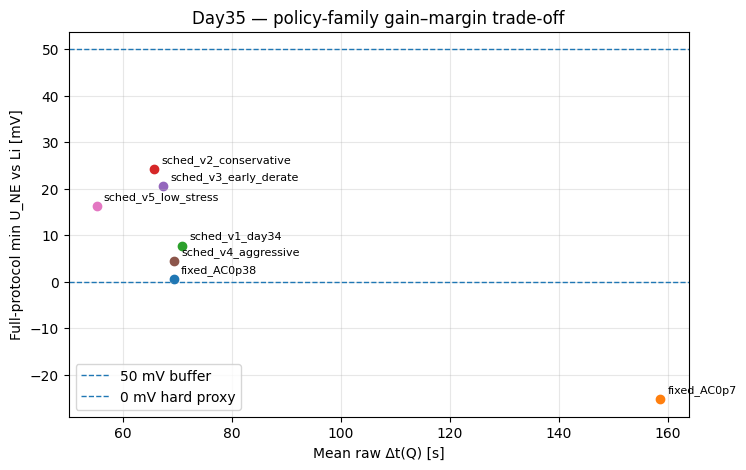

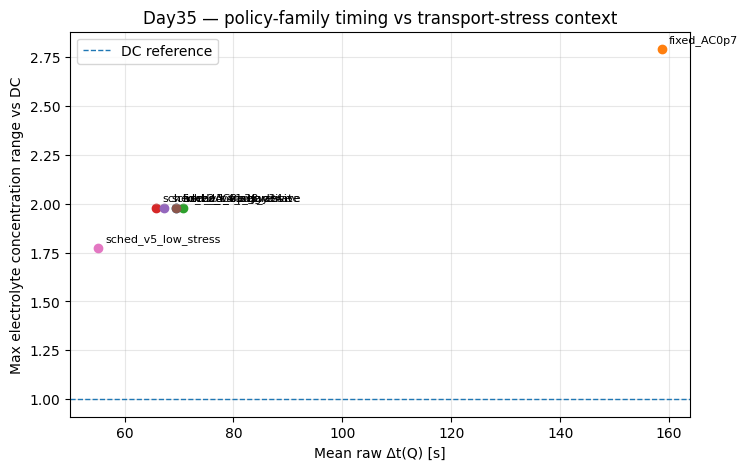

In [13]:
# Cell 13 — Plot Day35 policy gain–margin trade-off（绘制Day35策略收益-余量权衡）

plot_df = policy_ledger_df[policy_ledger_df["policy_id"] != "DC03"].copy()

fig, ax = plt.subplots(figsize=(8, 5))

for _, row in plot_df.iterrows():
    ax.scatter(row["delta_t_raw_mean_s"], row["min_U_NE_mV"])
    ax.annotate(
        row["policy_id"],
        (row["delta_t_raw_mean_s"], row["min_U_NE_mV"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

ax.axhline(50, linestyle="--", linewidth=1, label="50 mV buffer")
ax.axhline(0, linestyle="--", linewidth=1, label="0 mV hard proxy")
ax.set_xlabel("Mean raw Δt(Q) [s]")
ax.set_ylabel("Full-protocol min U_NE vs Li [mV]")
ax.set_title("Day35 — policy-family gain–margin trade-off")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in plot_df.iterrows():
    ax.scatter(row["delta_t_raw_mean_s"], row["max_c_e_range_vs_DC"])
    ax.annotate(
        row["policy_id"],
        (row["delta_t_raw_mean_s"], row["max_c_e_range_vs_DC"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

ax.axhline(1.0, linestyle="--", linewidth=1, label="DC reference")
ax.set_xlabel("Mean raw Δt(Q) [s]")
ax.set_ylabel("Max electrolyte concentration range vs DC")
ax.set_title("Day35 — policy-family timing vs transport-stress context")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


In [14]:
# Cell 14 — Day35 final policy-family synthesis（Day35策略族最终综合表）

final_df = policy_ledger_df.copy()

def recommend_policy(row):
    pid = row["policy_id"]

    if pid == "DC03":
        return "reference_only"
    if pid == "fixed_AC0p7":
        return "reject_not_admissible"
    if pid == "fixed_AC0p38":
        return "fixed_near_boundary_reference"
    if pid == "sched_v1_day34":
        return "proof_of_concept_baseline"
    if pid == "sched_v2_conservative":
        return "primary_rule_based_candidate"
    if pid == "sched_v3_early_derate":
        return "balanced_rule_based_candidate"
    if pid == "sched_v4_aggressive":
        return "deprioritize_late_derating"
    if pid == "sched_v5_low_stress":
        return "low_transport_stress_candidate"
    return "unclassified"


def policy_rationale(row):
    pid = row["policy_id"]

    if pid == "DC03":
        return "Pure DC reference; no raw DCAC timing gain."

    if pid == "fixed_AC0p7":
        return (
            "Largest raw gain but violates the hard 0 mV negative-electrode margin; "
            "stress case only, not an admissible candidate."
        )

    if pid == "fixed_AC0p38":
        return (
            "Fixed near-boundary baseline; preserves raw gain but operates extremely close "
            "to the 0 mV hard-margin proxy."
        )

    if pid == "sched_v1_day34":
        return (
            "Day34 proof-of-concept schedule; improves hard margin relative to fixed AC0.38 "
            "while retaining comparable raw timing gain."
        )

    if pid == "sched_v2_conservative":
        return (
            "Best first-generation rule-based candidate in this screen: substantial hard-margin "
            "improvement with only modest raw-gain sacrifice."
        )

    if pid == "sched_v3_early_derate":
        return (
            "Balanced candidate: slightly more raw gain than v2 with somewhat lower margin; "
            "useful as a less conservative alternative."
        )

    if pid == "sched_v4_aggressive":
        return (
            "Late derating retains little advantage over v1/fixed AC0.38 but leaves small margin; "
            "not preferred."
        )

    if pid == "sched_v5_low_stress":
        return (
            "Lower-transport-stress candidate; reduces max electrolyte-gradient amplification "
            "but sacrifices more timing gain."
        )

    return "No rationale assigned."


final_df["recommendation_class"] = final_df.apply(recommend_policy, axis=1)
final_df["recommendation_rationale"] = final_df.apply(policy_rationale, axis=1)

# A compact policy table for interpretation / closure.
day35_final_synthesis_df = final_df[
    [
        "policy_id",
        "case_role",
        "early_ac_c",
        "mid_ac_c",
        "late_ac_c",
        "qfrac_derate",
        "qfrac_ac_off",
        "delta_t_raw_mean_s",
        "delta_t_geom_mean_s",
        "delta_t_resid_mean_s",
        "dt_resid_class",
        "min_U_NE_mV",
        "margin_class",
        "fraction_time_below_0mV",
        "fraction_time_below_50mV",
        "max_c_e_range_vs_DC",
        "surface_range_at_min_vs_DC",
        "abs_eta_n_at_min_vs_DC",
        "policy_verdict",
        "microstate_context_class",
        "screening_score",
        "recommendation_class",
        "recommendation_rationale",
    ]
].copy()

# Ordering for display.
recommendation_order = {
    "primary_rule_based_candidate": 0,
    "balanced_rule_based_candidate": 1,
    "low_transport_stress_candidate": 2,
    "proof_of_concept_baseline": 3,
    "fixed_near_boundary_reference": 4,
    "reference_only": 5,
    "deprioritize_late_derating": 6,
    "reject_not_admissible": 7,
    "unclassified": 8,
}

day35_final_synthesis_df["recommendation_order"] = (
    day35_final_synthesis_df["recommendation_class"].map(recommendation_order).fillna(99)
)

day35_final_synthesis_df = day35_final_synthesis_df.sort_values(
    ["recommendation_order", "screening_score"],
    ascending=[True, False],
).reset_index(drop=True)

out = DATA_DIR / "day35_policy_family_final_synthesis.csv"
day35_final_synthesis_df.to_csv(out, index=False)

print("[OK] saved Day35 final synthesis:", out)

display_cols = [
    "policy_id",
    "recommendation_class",
    "delta_t_raw_mean_s",
    "min_U_NE_mV",
    "margin_class",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "abs_eta_n_at_min_vs_DC",
    "dt_resid_class",
    "screening_score",
    "recommendation_rationale",
]

display(day35_final_synthesis_df[display_cols])


# Simple recommended-candidate list for notebook closure.
recommended_candidates_df = day35_final_synthesis_df[
    day35_final_synthesis_df["recommendation_class"].isin([
        "primary_rule_based_candidate",
        "balanced_rule_based_candidate",
        "low_transport_stress_candidate",
    ])
].copy()

out = DATA_DIR / "day35_recommended_policy_candidates.csv"
recommended_candidates_df.to_csv(out, index=False)

print("[OK] saved recommended candidates:", out)
display(
    recommended_candidates_df[
        [
            "policy_id",
            "recommendation_class",
            "delta_t_raw_mean_s",
            "min_U_NE_mV",
            "max_c_e_range_vs_DC",
            "recommendation_rationale",
        ]
    ]
)


[OK] saved Day35 final synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day35_policy_family_final_synthesis.csv


,policy_id,recommendation_class,delta_t_raw_mean_s,min_U_NE_mV,margin_class,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,dt_resid_class,screening_score,recommendation_rationale
0,sched_v2_conservative,primary_rule_based_candidate,65.689082,24.160262,near_boundary,0.000000,1.978691,0.806120,1.520948,geometry_dominated,0.282025,Best first-generation rule-based candidate in ...
1,sched_v3_early_derate,balanced_rule_based_candidate,67.309795,20.499177,near_boundary,0.000000,1.978691,0.890900,1.265529,geometry_dominated,0.260994,Balanced candidate: slightly more raw gain tha...
2,sched_v5_low_stress,low_transport_stress_candidate,55.156123,16.256867,near_boundary,0.000000,1.773576,0.672516,1.396201,geometry_dominated,0.212211,Lower-transport-stress candidate; reduces max ...
3,sched_v1_day34,proof_of_concept_baseline,70.808641,7.750469,near_boundary,0.000000,1.978691,0.727920,1.534336,geometry_dominated,0.181676,Day34 proof-of-concept schedule; improves hard...
4,fixed_AC0p38,fixed_near_boundary_reference,69.350655,0.565686,near_boundary,0.000000,1.978691,1.086684,1.615777,geometry_dominated,0.127247,Fixed near-boundary baseline; preserves raw ga...
5,DC03,reference_only,0.000000,37.280562,near_boundary,0.000000,1.000000,1.000000,1.000000,dc_reference,0.260964,Pure DC reference; no raw DCAC timing gain.
6,sched_v4_aggressive,deprioritize_late_derating,69.350655,4.356615,near_boundary,0.000000,1.978691,0.809257,1.547650,geometry_dominated,0.153784,Late derating retains little advantage over v1...
7,fixed_AC0p7,reject_not_admissible,158.665349,-25.308203,risk_flag,0.039484,2.789566,1.141794,2.017561,geometry_dominated,-0.361375,Largest raw gain but violates the hard 0 mV ne...


[OK] saved recommended candidates: /Users/louislu/pybamm-dcac-superimposed/data/day35_recommended_policy_candidates.csv


,policy_id,recommendation_class,delta_t_raw_mean_s,min_U_NE_mV,max_c_e_range_vs_DC,recommendation_rationale
0,sched_v2_conservative,primary_rule_based_candidate,65.689082,24.160262,1.978691,Best first-generation rule-based candidate in ...
1,sched_v3_early_derate,balanced_rule_based_candidate,67.309795,20.499177,1.978691,Balanced candidate: slightly more raw gain tha...
2,sched_v5_low_stress,low_transport_stress_candidate,55.156123,16.256867,1.773576,Lower-transport-stress candidate; reduces max ...


## Final closure — Notebook 35

Notebook 35 extended the Day34 single scheduled waveform into a small, interpretable family of rule-based state-aware DC–AC scheduling policies.

The goal was not to perform global optimization, MPC, or Bayesian optimization. The goal was to screen a small policy family and identify first-generation gain–margin–microstate trade-off candidates.

The tested scheduled policies varied:

- early AC amplitude,
- mid AC amplitude,
- Q-based derating threshold,
- Q-based AC-off threshold.

All policies were evaluated under the same Chen2020 / DFN / isothermal / set-rebased `1.5τ_set` framework.

The timing result remained consistent with Day30–Day34:

- all DC–AC and scheduled policies produced geometry-dominated raw timing gain;
- `Δt_raw_mean ≈ Δt_geom_mean`;
- `Δt_resid_mean` remained near zero.

Therefore, Notebook 35 does not show non-geometric electrochemical acceleration. It evaluates scheduling policies mainly by how they trade prescribed-current raw timing gain against negative-electrode margin and microstate stress context.

The policy-family screen identifies three useful candidates:

1. **Primary rule-based candidate: `sched_v2_conservative`**

   - `early AC = 0.38C`
   - `mid AC = 0.10C`
   - derate at `0.70 Q_ref`
   - AC off at `0.80 Q_ref`
   - mean raw Δt(Q) ≈ 65.69 s
   - min U_NE ≈ +24.16 mV

   This policy gives the best first-generation hard-margin improvement with only modest raw-gain sacrifice relative to v1.

2. **Balanced candidate: `sched_v3_early_derate`**

   - `early AC = 0.38C`
   - `mid AC = 0.20C`
   - derate at `0.70 Q_ref`
   - AC off at `0.85 Q_ref`
   - mean raw Δt(Q) ≈ 67.31 s
   - min U_NE ≈ +20.50 mV

   This policy retains slightly more raw gain than v2 but with somewhat smaller margin.

3. **Low-transport-stress candidate: `sched_v5_low_stress`**

   - `early AC = 0.30C`
   - `mid AC = 0.10C`
   - derate at `0.75 Q_ref`
   - AC off at `0.85 Q_ref`
   - mean raw Δt(Q) ≈ 55.16 s
   - min U_NE ≈ +16.26 mV

   This policy lowers max electrolyte-gradient amplification but sacrifices more timing gain.

The fixed `AC0.7` stress baseline remains inadmissible despite its large raw timing gain:

- mean raw Δt(Q) ≈ 158.67 s
- min U_NE ≈ −25.31 mV
- hard-margin risk flag

The fixed `AC0.38` baseline and Day34 `sched_v1` remain useful references, but Day35 shows that earlier derating policies, especially v2 and v3, provide better hard-margin trade-offs.

Correct conclusion wording:

> The Day35 policy-family screen identifies `sched_v2_conservative` and `sched_v3_early_derate` as the best first-generation rule-based candidates. They retain geometry-dominated raw timing gain while substantially improving hard negative-electrode margin relative to fixed AC0.38 and Day34 v1. `sched_v5_low_stress` is a lower-transport-stress alternative with larger timing-gain sacrifice. The fixed AC0.7 stress case remains inadmissible.

Interpretation boundary:

- Notebook 35 evaluates a small hand-designed policy family.
- It does not perform global optimization.
- It does not implement MPC or Bayesian optimization.
- It does not evaluate thermal or aging admissibility.
- It does not prove experimental plating-free operation.
- It does not establish non-geometric electrochemical acceleration.
- The screening score is a qualitative ranking aid, not an optimizer or physical law.

Next step:

The next-stage work can turn this policy family into an MPC / Bayesian-optimization-ready parameterization. The candidate design variables are:

- early AC amplitude,
- mid AC amplitude,
- derating threshold,
- AC-off threshold,
- peak-current ceiling,
- future voltage / U_NE / thermal feedback thresholds.
